# Perform Principal Component Analysis (PCA) for Figure 2d
- use scikit-learn (sklearn) to visualize the relationship (dominate axes of variation) across antibody properties alongsize number of mutations acquired (compared to germline) 

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_paths = {
    'wuhan':      '../../../epistasis_inference/linear_interaction_models/wuhan/reference-based/predicted_phenotypes/wuhan_raw_2order_full_biochem_predictions.csv',
    'ba1':        '../../../epistasis_inference/linear_interaction_models/ba1/reference-based/predicted_phenotypes/ba1_raw_3order_full_biochem_predictions.csv',
    'ba4':        '../../../epistasis_inference/linear_interaction_models/ba4/reference-based/predicted_phenotypes/ba4_raw_3order_full_biochem_predictions.csv',
    'expression': '../../../epistasis_inference/linear_interaction_models/expression/reference-based/predicted_phenotypes/expression_raw_2order_full_biochem_predictions.csv',
    'psr':        '../../../epistasis_inference/linear_interaction_models/psr/reference-based/predicted_phenotypes/psr_raw_2order_full_biochem_predictions.csv',
}

dataframes = []
for prefix, path in file_paths.items():
    df = pd.read_csv(path, dtype={'geno': str})
    new_columns = {col: f"{prefix}_{col}" for col in df.columns if col != 'geno'}
    df.rename(columns=new_columns, inplace=True)
    print(f"Loaded {prefix}: shape {df.shape}, columns: {list(df.columns)}")
    dataframes.append(df)

merged_df = dataframes[0]
for i, df in enumerate(dataframes[1:], 1):
    merged_df = pd.merge(merged_df, df, on='geno', how='outer')
    print(f"After merging file {i+1}: shape {merged_df.shape}")

print(f"\nFinal merged shape: {merged_df.shape}")
print(f"Geno column dtype: {merged_df['geno'].dtype}")
print(f"Columns: {list(merged_df.columns)}")

Loaded wuhan: shape (8192, 3), columns: ['geno', 'wuhan_predicted_phenotype', 'wuhan_prediction_se']
Loaded ba1: shape (8192, 3), columns: ['geno', 'ba1_predicted_phenotype', 'ba1_prediction_se']
Loaded ba4: shape (8192, 3), columns: ['geno', 'ba4_predicted_phenotype', 'ba4_prediction_se']
Loaded expression: shape (8192, 3), columns: ['geno', 'expression_predicted_phenotype', 'expression_prediction_se']
Loaded psr: shape (8192, 3), columns: ['geno', 'psr_predicted_phenotype', 'psr_prediction_se']
After merging file 2: shape (8192, 5)
After merging file 3: shape (8192, 7)
After merging file 4: shape (8192, 9)
After merging file 5: shape (8192, 11)

Final merged shape: (8192, 11)
Geno column dtype: object
Columns: ['geno', 'wuhan_predicted_phenotype', 'wuhan_prediction_se', 'ba1_predicted_phenotype', 'ba1_prediction_se', 'ba4_predicted_phenotype', 'ba4_prediction_se', 'expression_predicted_phenotype', 'expression_prediction_se', 'psr_predicted_phenotype', 'psr_prediction_se']


In [3]:
#define mutation positions and add binary indicator columns for each position, where 0 indicates a wild-type (germline) amino acid and 1 indicates a mature (bnAb) amino acid at that position
def find_pos_1(variant):
    pos = [mut for mut in variant]
    if pos[0] == "1":
        return 1
    else:
        return 0
def find_pos_2(variant):
    pos = [mut for mut in variant]
    if pos[1] == "1":
        return 1
    else:
        return 0
def find_pos_3(variant):
    pos = [mut for mut in variant]
    if pos[2] == "1":
        return 1
    else:
        return 0
def find_pos_4(variant):
    pos = [mut for mut in variant]
    if pos[3] == "1":
        return 1
    else:
        return 0
def find_pos_5(variant):
    pos = [mut for mut in variant]
    if pos[4] == "1":
        return 1
    else:
        return 0
def find_pos_6(variant):
    pos = [mut for mut in variant]
    if pos[5] == "1":
        return 1
    else:
        return 0
def find_pos_7(variant):
    pos = [mut for mut in variant]
    if pos[6] == "1":
        return 1
    else:
        return 0
def find_pos_8(variant):
    pos = [mut for mut in variant]
    if pos[7] == "1":
        return 1
    else:
        return 0
def find_pos_9(variant):
    pos = [mut for mut in variant]
    if pos[8] == "1":
        return 1
    else:
        return 0
def find_pos_10(variant):
    pos = [mut for mut in variant]
    if pos[9] == "1":
        return 1
    else:
        return 0
def find_pos_11(variant):
    pos = [mut for mut in variant]
    if pos[10] == "1":
        return 1
    else:
        return 0
def find_pos_12(variant):
    pos = [mut for mut in variant]
    if pos[11] == "1":
        return 1
    else:
        return 0
def find_pos_13(variant):
    pos = [mut for mut in variant]
    if pos[12] == "1":
        return 1
    else:
        return 0
def find_pos_14(variant):
    pos = [mut for mut in variant]
    if pos[13] == "1":
        return 1
    else:
        return 0
    
def find_pos_345(geno):
    pos = [mut for mut in geno]
    if pos[2] == "1" and pos[3] == "1" and pos[4] == "1":
        return "111"
    elif pos[2] == "1" and pos[3] == "0" and pos[4] == "0":
        return "100"
    elif pos[2] == "0" and pos[3] == "1" and pos[4] == "0":
        return "010"
    elif pos[2] == "0" and pos[3] == "0" and pos[4] == "1":
        return "001"
    elif pos[2] == "1" and pos[3] == "1" and pos[4] == "0":
        return "110"
    elif pos[2] == "1" and pos[3] == "0" and pos[4] == "1":
        return "101"
    elif pos[2] == "0" and pos[3] == "1" and pos[4] == "1":
        return "011"
    elif pos[2] == "0" and pos[3] == "0" and pos[4] == "0":
        return "000"
    
#add a column with the number of mutations
def sum_digits(digit):
    return sum(int(x) for x in digit if x.isdigit())

merged_df['pos1'] = merged_df['geno'].apply(find_pos_1)
merged_df['pos2'] = merged_df['geno'].apply(find_pos_2)
merged_df['pos3'] = merged_df['geno'].apply(find_pos_3)
merged_df['pos4'] = merged_df['geno'].apply(find_pos_4)
merged_df['pos5'] = merged_df['geno'].apply(find_pos_5)
merged_df['pos6'] = merged_df['geno'].apply(find_pos_6)
merged_df['pos7'] = merged_df['geno'].apply(find_pos_7)
merged_df['pos8'] = merged_df['geno'].apply(find_pos_8)
merged_df['pos9'] = merged_df['geno'].apply(find_pos_9)
merged_df['pos10'] = merged_df['geno'].apply(find_pos_10)
merged_df['pos11'] = merged_df['geno'].apply(find_pos_11)
merged_df['pos12'] = merged_df['geno'].apply(find_pos_12)
merged_df['pos13'] = merged_df['geno'].apply(find_pos_13)
merged_df['pos345'] = merged_df['geno'].apply(find_pos_345)
merged_df['som_mut'] = merged_df['geno'].apply(sum_digits)

merged_df

,geno,wuhan_predicted_phenotype,wuhan_prediction_se,ba1_predicted_phenotype,ba1_prediction_se,ba4_predicted_phenotype,ba4_prediction_se,expression_predicted_phenotype,expression_prediction_se,psr_predicted_phenotype,...,pos6,pos7,pos8,pos9,pos10,pos11,pos12,pos13,pos345,som_mut
0,0000000000000,6.709208,0.043057,7.398105,0.069789,6.874339,0.059526,4.227666,0.014119,2.122274,...,0,0,0,0,0,0,0,0,000,0
1,0000000000001,6.734938,0.043413,7.484630,0.067803,6.835322,0.059259,4.226895,0.014095,2.103620,...,0,0,0,0,0,0,0,1,000,1
2,0000000000010,6.908735,0.043410,8.565534,0.068491,7.073525,0.060144,4.194454,0.014110,2.151228,...,0,0,0,0,0,0,1,0,000,1
3,0000000000011,6.898220,0.044091,8.698161,0.067024,7.039201,0.060009,4.187310,0.014093,2.143346,...,0,0,0,0,0,0,1,1,000,2
4,0000000000100,7.620991,0.042388,7.389404,0.068265,7.173606,0.059508,4.246568,0.014097,2.083507,...,0,0,0,0,0,1,0,0,000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8187,1111111111011,9.394916,0.041741,9.867449,0.065934,9.081209,0.059595,4.316802,0.014088,1.508107,...,1,1,1,1,1,0,1,1,111,12
8188,1111111111100,9.385906,0.042341,9.602998,0.066862,9.125959,0.061031,4.288365,0.014084,1.631728,...,1,1,1,1,1,1,0,0,111,11
8189,1111111111101,9.454361,0.041507,9.671887,0.065941,9.069895,0.059882,4.307475,0.014091,1.675741,...,1,1,1,1,1,1,0,1,111,12
8190,1111111111110,9.461726,0.041949,9.818912,0.066338,9.001754,0.059615,4.311562,0.014082,1.554912,...,1,1,1,1,1,1,1,0,111,12


Explained variance ratios: [0.55647844 0.29432931]


/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_2257/2942036017.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


Saved: som_mut.png


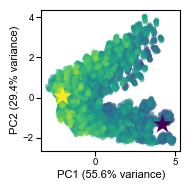

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Arial'

# preserve leading zeros
merged_df["geno"] = merged_df["geno"].astype(str)

feature_cols = [
    "wuhan_predicted_phenotype",
    "ba1_predicted_phenotype",
    "ba4_predicted_phenotype",
    "expression_predicted_phenotype",
    "psr_predicted_phenotype",
]

# standardize features (mean = 0 and std = 1 for each dataset)and run PCA
X = merged_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

print("Explained variance ratios:", pca.explained_variance_ratio_)

# average PCs per genotype and flip axes for interpretability
pc_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=merged_df.index)
pc_df["geno"] = merged_df["geno"]

pc_by_geno = pc_df.groupby("geno", as_index=False)[["PC1", "PC2"]].mean()
pc_by_geno["PC1"] = -pc_by_geno["PC1"]
pc_by_geno["PC2"] = -pc_by_geno["PC2"]

# merge PCs back into main dataframe
merged_df = merged_df.drop(columns=["PC1", "PC2"], errors="ignore")
merged_df = merged_df.merge(pc_by_geno, on="geno", how="left")

# compute PCA loadings
pc_loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=["PC1", "PC2"]
)

# export merged dataframe and PCA loadings
merged_df.to_csv("antibody_library_with_PC1_PC2_pred.csv", index=False)
pc_loadings.to_csv("pca_loadings_pred.csv", index=False)

# identify germline and Omi32 genotypes
germline_geno = "0" * len(merged_df["geno"].iloc[0])
omi32_geno    = "1" * len(merged_df["geno"].iloc[0])
has_germline  = germline_geno in merged_df["geno"].values
has_omi32     = omi32_geno    in merged_df["geno"].values

# set up colormap for som_mut
color_by = "som_mut"
vmin, vmax = merged_df[color_by].min(), merged_df[color_by].max()
cmap = cm.get_cmap("viridis")
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

os.makedirs("images", exist_ok=True)

# plot PCA colored by number of somatic mutations
fig, ax = plt.subplots(figsize=(2, 2))

ax.scatter(
    merged_df["PC1"], merged_df["PC2"],
    c=merged_df[color_by],
    cmap="viridis", vmin=vmin, vmax=vmax,
    s=15, alpha=0.6, linewidths=0
)

# overlay star markers for germline and Omi32
if has_germline:
    g = merged_df[merged_df["geno"] == germline_geno].iloc[0]
    ax.scatter(g["PC1"], g["PC2"],
               marker='*', s=200, c=[cmap(norm(g[color_by]))],
               linewidths=0, zorder=10)

if has_omi32:
    o = merged_df[merged_df["geno"] == omi32_geno].iloc[0]
    ax.scatter(o["PC1"], o["PC2"],
               marker='*', s=200, c=[cmap(norm(o[color_by]))],
               linewidths=0, zorder=10)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=8, labelpad=2)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=8, labelpad=2)

# set x-ticks at 0 and 5 with integer formatting
ax.set_xticks([0, 5])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

ax.tick_params(labelsize=7, pad=2)
ax.set_title("", fontsize=8)

plt.tight_layout()

# save figure
plt.savefig(os.path.join("images", "Figure_2d.png"),
            format="png", transparent=True, dpi=2000, bbox_inches="tight")
print("Saved: som_mut.png")
plt.show()
plt.close()


In [5]:
df.to_csv(
    "omi32_pca_export.csv",
    index=False
)